In [5]:
import pandas as pd 
import numpy as np
import seaborn  as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("IPL.csv")
df.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18


1. Total number of matches played

In [7]:
df["match_id"].count()

np.int64(74)

2. How many teams are present?

In [8]:
teams = pd.concat([df["team1"],df["team2"]]).unique()
print(f"Toatal Teams in IPL i 2022 = {len(teams)}")


Toatal Teams in IPL i 2022 = 10


3. Show unique team names

In [9]:
teams = pd.concat([df["team1"],df["team2"]]).unique()
print(teams)

<StringArray>
[  'Chennai',     'Delhi',  'Banglore',   'Gujarat', 'Hyderabad',   'Kolkata',
    'Mumbai',   'Lucknow',    'Punjab', 'Rajasthan']
Length: 10, dtype: str


4. Which stadium hosted most matches?

In [10]:
mostmatch = df.value_counts("venue")
mostmatch.head(1)

venue
Wankhede Stadium, Mumbai    21
Name: count, dtype: int64

5. Which city hosted most matches?

In [42]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,City,day
0,1,1-03-26,"Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,Mumbai,Monday
1,2,1-03-27,"Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,Mumbai,Tuesday
2,3,1-03-27,"Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,Mumbai,Tuesday
3,4,1-03-28,"Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,Mumbai,Wednesday
4,5,1-03-29,"Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,Pune,Thursday


In [12]:
df["City"] = df["venue"].apply(lambda x: x.split(",")[1] )

Text(0.5, 1.0, 'Total match in Cities')

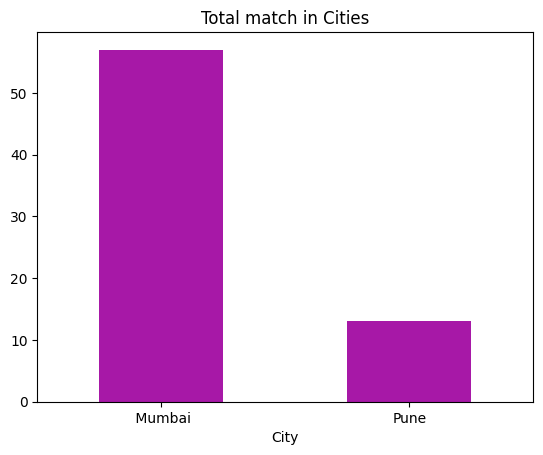

In [41]:
city = df["City"].value_counts().head(2)
sns.barplot(x =city.index,y=city.values,width=0.5,color="m")
plt.title("Total match in Cities")

6. Count matches played day-wise

In [ ]:
df['date'] =pd.to_datetime(df['date'])


In [19]:
df['day'] =  df["date"].dt.day_name()



C:\Users\sharn\AppData\Local\Temp\ipykernel_1896\1142413611.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x =count.index,y=count.values,palette="rainbow")


<Axes: xlabel='day'>

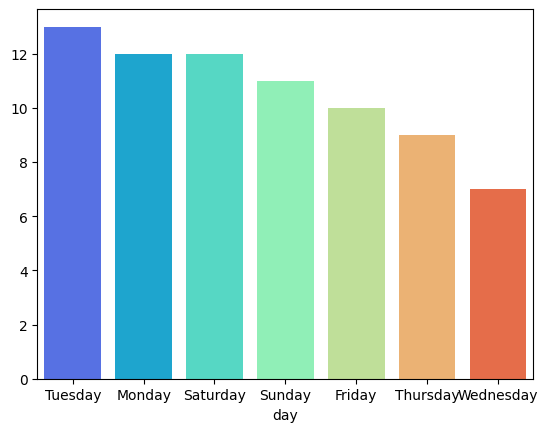

In [30]:
count = df.value_counts("day")
sns.barplot(x =count.index,y=count.values,palette="rainbow")

7. Count matches played night-wise

In [43]:
df['hour'] = df['date'].dt.hour
df['match_shift'] = df['hour'].apply(
    lambda x: 'Day' if x < 18 else 'Night'
)

print(df['match_shift'].value_counts())

match_shift
Day    74
Name: count, dtype: int64


8. Which team won most matches?

In [45]:
df.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,City,day,hour,match_shift
0,1,1-03-26,"Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,Mumbai,Monday,0,Day
1,2,1-03-27,"Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,Mumbai,Tuesday,0,Day


C:\Users\sharn\AppData\Local\Temp\ipykernel_1896\2671208966.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_win_match.index,y=most_win_match.values,width=0.7,palette="brg")


<Axes: xlabel='match_winner'>

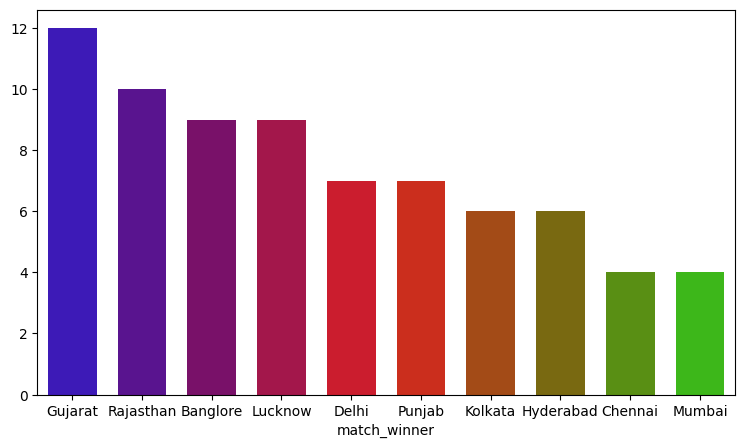

In [55]:
most_win_match = df["match_winner"].value_counts()
plt.figure(figsize=(9,5))
sns.barplot(x=most_win_match.index,y=most_win_match.values,width=0.7,palette="brg")


9. Top 5 winning teams

C:\Users\sharn\AppData\Local\Temp\ipykernel_1896\2017663184.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_win_match.index,y=most_win_match.values,width=0.7,palette="brg")


Text(0, 0.5, 'Match_Win')

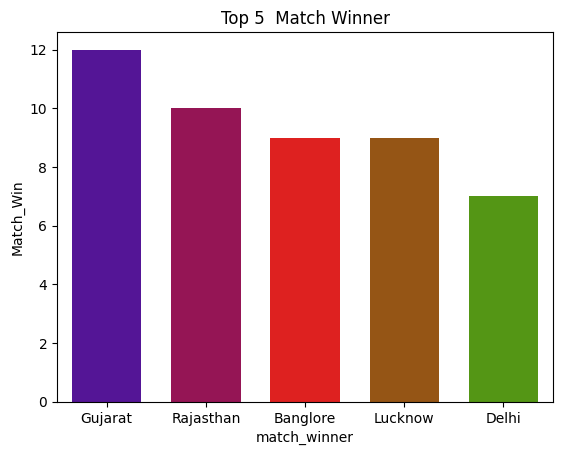

In [59]:
most_win_match = df["match_winner"].value_counts().head(5)
sns.barplot(x=most_win_match.index,y=most_win_match.values,width=0.7,palette="brg")
plt.title("Top 5  Match Winner")
plt.ylabel("Match_Win")


10. Which team lost most matches?

In [60]:
df['match_winner'].value_counts().tail(1)

match_winner
Mumbai    4
Name: count, dtype: int64

11. Which team won most tosses?

In [62]:
df.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,City,day,hour,match_shift
0,1,1-03-26,"Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,Mumbai,Monday,0,Day
1,2,1-03-27,"Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,Mumbai,Tuesday,0,Day


C:\Users\sharn\AppData\Local\Temp\ipykernel_1896\1162986427.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(toss_win,palette="Set1")


<Axes: xlabel='toss_winner', ylabel='count'>

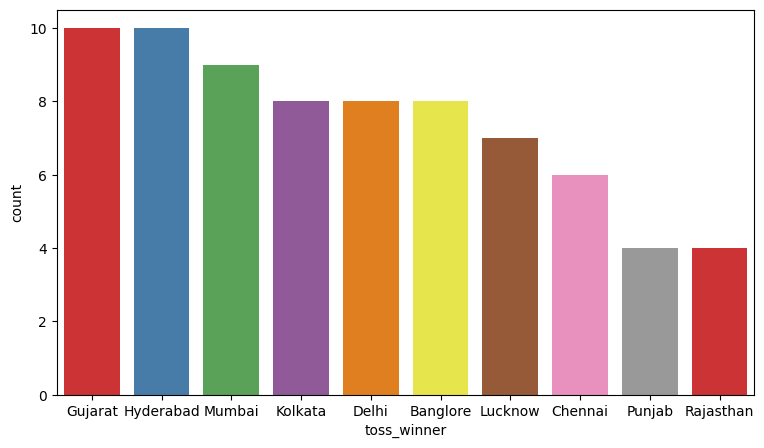

In [66]:
toss_win = df["toss_winner"].value_counts()
plt.figure(figsize=(9,5))
sns.barplot(toss_win,palette="Set1")

12. Does toss winner also win match?

C:\Users\sharn\AppData\Local\Temp\ipykernel_1896\3514713304.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(toss,palette="viridis")


Text(0.5, 1.0, 'Toss winner wins Matches')

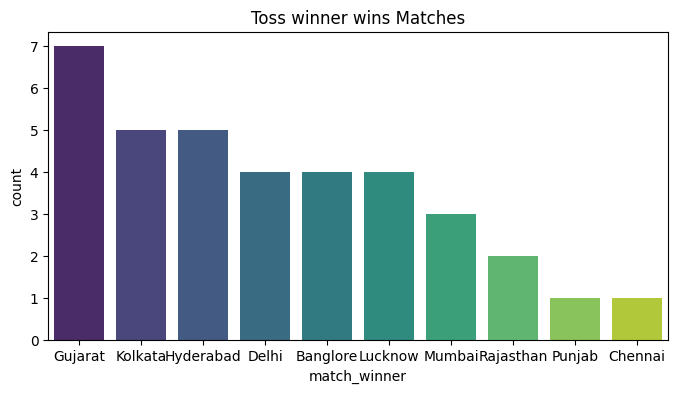

In [77]:
toss = df[df["match_winner"]==df["toss_winner"]]["match_winner"].value_counts()
plt.figure(figsize=(8,4))
sns.barplot(toss,palette="viridis")
plt.title("Toss winner wins Matches")

13. Which team won most matches while batting first?

In [80]:
df.head(1)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,City,day,hour,match_shift
0,1,1-03-26,"Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,Mumbai,Monday,0,Day


C:\Users\sharn\AppData\Local\Temp\ipykernel_1896\1138485505.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(bat_first,palette="dark")


Text(0.5, 1.0, 'Bat first and win Match.')

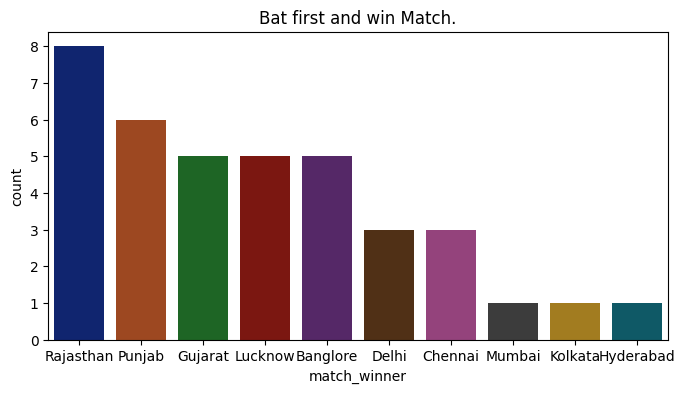

In [101]:
def batting_first_team(txt):
    if txt['toss_decision'] == 'bat':
        return txt['toss_winner']
    else:
        if txt['toss_winner'] == txt['team1']:
            return txt['team2']
        else:
            return txt['team1']

df['bat_first_team'] = df.apply(batting_first_team, axis=1)

result = df[df['bat_first_team'] == df['match_winner']]
bat_first =  result["match_winner"].value_counts()
plt.figure(figsize=(8,4))
sns.barplot(bat_first,palette="dark")
plt.title("Bat first and win Match.")


14. Which team won most matches while chasing?

C:\Users\sharn\AppData\Local\Temp\ipykernel_1896\830365521.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(bat_first,palette="rainbow")


Text(0.5, 1.0, 'Bowling first and win Match.')

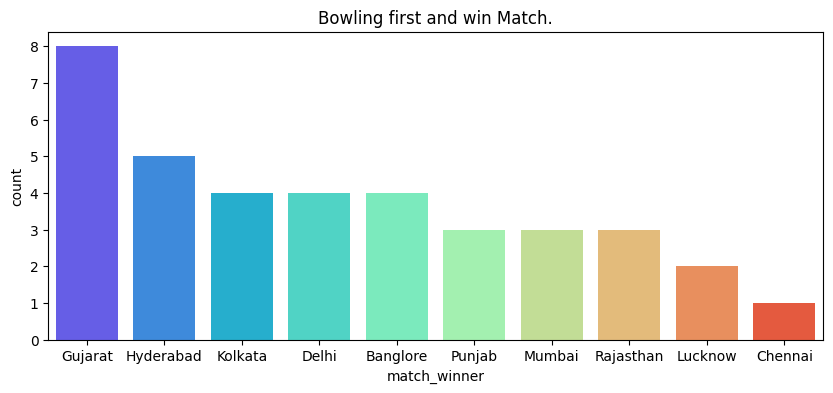

In [107]:
def bowling_first_team(txt):
    if txt['toss_decision'] == 'Field':
        return txt['toss_winner']
    else:
        if txt['toss_winner'] == txt['team1']:
            return txt['team2']
        else:
            return txt['team1']

df['bowl_first_team'] = df.apply(bowling_first_team, axis=1)

result = df[df['bowl_first_team'] == df['match_winner']]
bat_first =  result["match_winner"].value_counts()
plt.figure(figsize=(10,4))
sns.barplot(bat_first,palette="rainbow")
plt.title("Bowling first and win Match.")